<a href="https://colab.research.google.com/github/mpconsultsai/msc-project-csc-40098/blob/main/training/notebooks/training_text_tfidf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text training — TF-IDF baseline (RQ1)

The simplest text baseline: TF-IDF features + logistic regression on the frozen `fake_news_final_text.tsv` cohort. A **CPU runtime is fine** (training takes ~2 s). It also writes `tfidf_pipeline.joblib`, used by the demo UI. Setup steps are in the cell below.

The other modalities have their own notebooks: `training_text_distilbert.ipynb`, `training_image_resnet.ipynb`, and `training_fusion.ipynb`.

## How to run this notebook (Google Colab)

**What it does:** trains and evaluates the **TF-IDF text baseline**. A **CPU runtime is fine** — no GPU needed (training takes a few seconds).

**Before you run:**
1. **Add the shared project folder to your Google Drive** (one-time) so these paths exist — the setup cell reads them:
   - `My Drive/training/src/` — helper modules (`colab_setup.py`, `cohort_*.py`)
   - `My Drive/data/fake_news_final_text.tsv` — the frozen text cohort (~17 MB)

   If the folder was *shared with you*, open it in Drive and click **“Add shortcut to Drive”** so it appears under `My Drive/`.
2. **Set the runtime:** `Runtime → Change runtime type → CPU`.
3. **(Recommended)** `File → Save a copy in Drive` so your edits and outputs persist.

**Then `Runtime → Run all`** (or run the cells top to bottom in order):
- **Bootstrap** — mounts Drive and copies `training/` into the session.
- **Colab setup** — installs the pinned dependencies (`install_dependencies()`) and copies the TSV in.
- The remaining cells train and evaluate, writing results to `runs/text_tfidf_baseline/`.

> **Troubleshooting**
> - `No module named 'google'` → you’re not on a hosted Colab runtime. Open this in the Colab browser tab and connect to a **hosted** runtime (not “local”).
> - `No module named 'colab_setup'` → the **Bootstrap** cell hasn’t run successfully yet, or `My Drive/training/src/` is missing. Run Bootstrap first and confirm the Drive layout above.

## Decisions (defaults)

| Area | Choice |
|------|--------|
| Data | `cohort_text.load_text_cohort()` — 48,878 rows, pooled train/val |
| Model | `TfidfVectorizer` (50k features, 1–2 grams, `min_df=5`) + `LogisticRegression` (`class_weight="balanced"`, seed 42) |
| Tuning | **None** (fixed hyperparameters) |
| Metrics | Macro-F1 (primary), accuracy, ROC-AUC, average precision, classification report, confusion matrix |
| Threshold | Default **0.5** for accuracy / F1 / report; curves use `score_fake` (no tuning) |
| Output | `runs/text_tfidf_baseline/` — includes **`tfidf_pipeline.joblib`** for Gradio PoC inference |

## Setup

Run the cells below in order: **bootstrap** (mounts Drive, copies `training/` in) then the **setup** cell (installs the pinned dependencies and copies the TSV in). No GPU required.

In [1]:
# Bootstrap — mount Drive and copy training/ (identical cell in all Colab notebooks)
import shutil
import sys
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/msc")
TRAINING_SRC = Path("/content/drive/MyDrive/training")
TRAINING = PROJECT_ROOT / "training"
if not TRAINING_SRC.is_dir():
    raise FileNotFoundError(
        "Sync repo training/ to My Drive/training/ (modules under training/src/)"
    )
if TRAINING.exists():
    shutil.rmtree(TRAINING)
shutil.copytree(TRAINING_SRC, TRAINING)
sys.path.insert(0, str(TRAINING / "src"))
print("PROJECT_ROOT:", PROJECT_ROOT, "| training:", TRAINING)

Mounted at /content/drive
PROJECT_ROOT: /content/msc | training: /content/msc/training


In [2]:
from colab_setup import install_dependencies, setup_colab_project

# Pinned, version-synced installs (single source of truth: colab_setup.PINNED_DEPENDENCIES).
install_dependencies()  # base only (scikit-learn, pandas); CPU runtime is fine

ctx = setup_colab_project(
    tsv_names=["fake_news_final_text.tsv"],
    need_images=False,
)
PROJECT_ROOT = ctx.project_root

Installing pinned dependencies: scikit-learn==1.5.2 pandas==2.2.2
Resolved dependency versions:
    scikit-learn: 1.5.2
          pandas: 2.2.2
           torch: 2.11.0+cpu
     torchvision: 0.26.0+cpu
TSV: /content/msc/data/fake_news_final_text.tsv
Training helpers: /content/msc/training
Setup OK: ColabSetup(project_root=PosixPath('/content/msc'), data_dir=PosixPath('/content/msc/data'), training_dir=PosixPath('/content/msc/training'), images_dir=PosixPath('/content/msc/data/processed/images'), image_count=0, tsv_paths={'fake_news_final_text.tsv': PosixPath('/content/msc/data/fake_news_final_text.tsv')})


In [3]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

_training_dir = Path("/content/msc/training/src")
if not (_training_dir / "cohort_text.py").is_file():
    _training_dir = Path.cwd() / "training" / "src"
    if not (_training_dir / "cohort_text.py").is_file():
        _training_dir = Path.cwd() if (Path.cwd() / "cohort_text.py").is_file() else _training_dir
if str(_training_dir) not in sys.path:
    sys.path.insert(0, str(_training_dir))

from cohort_text import (
    RANDOM_SEED,
    load_text_cohort,
    resolve_project_root,
    train_val_frames,
)

# Colab setup sets PROJECT_ROOT; when run locally, repo root is discovered from cwd.
_root_hint = globals().get("PROJECT_ROOT")
PROJECT_ROOT = resolve_project_root(_root_hint)
RUN_DIR = PROJECT_ROOT / "runs" / "text_tfidf_baseline"
RUN_ID = "text_tfidf_baseline"
RUN_DIR.mkdir(parents=True, exist_ok=True)

df_text = load_text_cohort(PROJECT_ROOT)
train_df, val_df = train_val_frames(df_text)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("train_all:", len(train_df), "| val_all:", len(val_df))
display(
    df_text.groupby(["dataset", "split_study"], dropna=False)
    .size()
    .to_frame("count")
    .reset_index()
    .sort_values(["dataset", "split_study"])
)

PROJECT_ROOT: /content/msc
train_all: 44090 | val_all: 4788


,dataset,split_study,count
0,fakeddit,train,42954
1,fakeddit,validation,4504
2,fakenewsnet,train,1136
3,fakenewsnet,validation,284


In [4]:
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

text_clf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                min_df=5,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

t0 = time.perf_counter()
text_clf.fit(train_df["text"], train_df["label_binary"])
train_seconds = time.perf_counter() - t0

print(f"Training finished in {train_seconds:.2f} s")
print(f"Vocabulary size: {len(text_clf.named_steps['tfidf'].vocabulary_)}")

Training finished in 8.02 s
Vocabulary size: 40501


Validation metrics (pooled val_all, threshold=0.5):
  accuracy:  0.7707
  macro_f1:  0.7696
  roc_auc:   0.8470
  avg_prec:  0.8560  (area under PR curve)
  train_seconds: 8.0222
  infer_ms_per_1k_val: 0.1958

              precision    recall  f1-score   support

    real (0)       0.74      0.77      0.75      2176
    fake (1)       0.80      0.77      0.79      2612

    accuracy                           0.77      4788
   macro avg       0.77      0.77      0.77      4788
weighted avg       0.77      0.77      0.77      4788



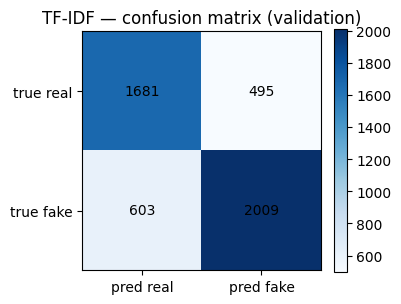

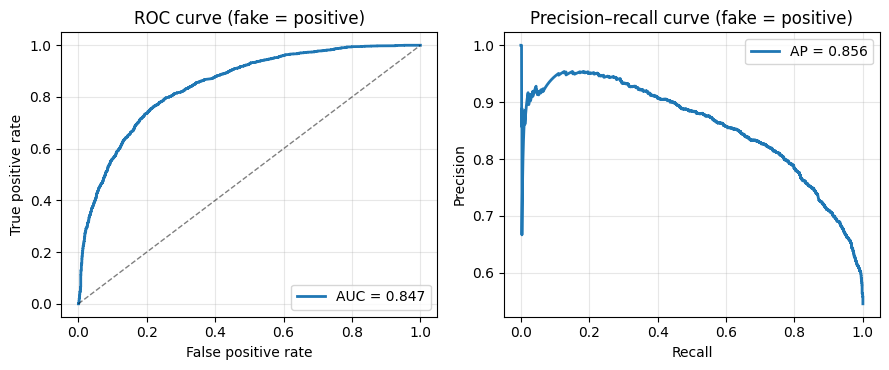

,sample_id,dataset,y_true,y_pred,score_fake
42954,fd:151xr9,fakeddit,1,1,0.690141
42955,fd:ba8djo,fakeddit,1,1,0.844485
42956,fd:9cjhoa,fakeddit,0,0,0.108090
42957,fd:9am49y,fakeddit,0,0,0.309782
42958,fd:d7hb1v,fakeddit,1,1,0.705047


Persisted to Drive: /content/drive/MyDrive/runs/text_tfidf_baseline
Persisted to My Drive/runs/text_tfidf_baseline/ (includes tfidf_pipeline.joblib)
Saved:
  runs/text_tfidf_baseline/metrics.json
  runs/text_tfidf_baseline/tfidf_pipeline.joblib
  runs/text_tfidf_baseline/predictions_val.tsv
  runs/text_tfidf_baseline/confusion_matrix.png
  runs/text_tfidf_baseline/roc_pr_curves.png


In [5]:
import json
import time

import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)

X_val = val_df["text"]
y_val = val_df["label_binary"]

t0 = time.perf_counter()
y_pred = text_clf.predict(X_val)
y_score = text_clf.predict_proba(X_val)[:, 1]
infer_seconds = time.perf_counter() - t0

acc = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average="macro")
roc_auc = roc_auc_score(y_val, y_score)
avg_precision = average_precision_score(y_val, y_score)

metrics = {
    "run_id": RUN_ID,
    "model": "tfidf_logistic_regression",
    "split_policy": "fakeddit_official_plus_fnn_80_20_seed_42",
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "f1_real": float(f1_score(y_val, y_pred, pos_label=0)),
    "f1_fake": float(f1_score(y_val, y_pred, pos_label=1)),
    "recall_real": float(recall_score(y_val, y_pred, pos_label=0)),
    "recall_fake": float(recall_score(y_val, y_pred, pos_label=1)),
    "roc_auc": float(roc_auc),
    "average_precision": float(avg_precision),
    "train_seconds": round(train_seconds, 4),
    "infer_seconds_val": round(infer_seconds, 4),
    "infer_ms_per_1k_val": round(infer_seconds / len(val_df) * 1000, 4),
    "random_seed": RANDOM_SEED,
    "sklearn_version": sklearn.__version__,
}

print("Validation metrics (pooled val_all, threshold=0.5):")
print(f"  accuracy:  {acc:.4f}")
print(f"  macro_f1:  {macro_f1:.4f}")
print(f"  roc_auc:   {roc_auc:.4f}")
print(f"  avg_prec:  {avg_precision:.4f}  (area under PR curve)")
print(f"  train_seconds: {metrics['train_seconds']}")
print(f"  infer_ms_per_1k_val: {metrics['infer_ms_per_1k_val']}")
print()
print(classification_report(y_val, y_pred, target_names=["real (0)", "fake (1)"]))

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fig_cm, ax_cm = plt.subplots(figsize=(4, 3.5))
im = ax_cm.imshow(cm, cmap="Blues")
ax_cm.set_xticks([0, 1], labels=["pred real", "pred fake"])
ax_cm.set_yticks([0, 1], labels=["true real", "true fake"])
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
ax_cm.set_title("TF-IDF — confusion matrix (validation)")
fig_cm.colorbar(im, ax=ax_cm, fraction=0.046)
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val, y_score)
prec, rec, _ = precision_recall_curve(y_val, y_score)

fig_curves, axes = plt.subplots(1, 2, figsize=(9, 3.8))

axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (fake = positive)")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, lw=2, label=f"AP = {avg_precision:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall curve (fake = positive)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

pred_df = val_df[["sample_id", "dataset"]].copy()
pred_df["y_true"] = y_val.values
pred_df["y_pred"] = y_pred
pred_df["score_fake"] = y_score
display(pred_df.head())

metrics_path = RUN_DIR / "metrics.json"
pred_path = RUN_DIR / "predictions_val.tsv"
cm_path = RUN_DIR / "confusion_matrix.png"
curves_path = RUN_DIR / "roc_pr_curves.png"
pipeline_path = RUN_DIR / "tfidf_pipeline.joblib"

import joblib

with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)
joblib.dump(text_clf, pipeline_path)
pred_df.to_csv(pred_path, sep="\t", index=False)
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")
fig_curves.savefig(curves_path, dpi=150, bbox_inches="tight")

if Path("/content/drive/MyDrive").is_dir():
    from colab_setup import persist_run_to_drive

    persist_run_to_drive(RUN_DIR)
    print("Persisted to My Drive/runs/text_tfidf_baseline/ (includes tfidf_pipeline.joblib)")

print("Saved:")
print(" ", metrics_path.relative_to(PROJECT_ROOT))
print(" ", pipeline_path.relative_to(PROJECT_ROOT))
print(" ", pred_path.relative_to(PROJECT_ROOT))
print(" ", cm_path.relative_to(PROJECT_ROOT))
print(" ", curves_path.relative_to(PROJECT_ROOT))

### Done

TF-IDF baseline complete. Metrics in `runs/text_tfidf_baseline/`.

**Next:** `training_text_distilbert.ipynb` on Colab for transfer baseline.
